#Problem Statement


This project started because I wanted to learn more about networking attacks and how I could apply machine learning techniques in addition to topics I've learned in class to see what features of flows from network data would be the most important to classifying attacks.

# Research on the IDS-CIC2017
With the advancements of technology in the past decade, network attacks too have evolved with the emerging tech. Intrusion Detection Systems are integral defense tools against these attacks. However, testing and research for these IDS technology often used outdated and unreliable data to create analysis.


Researchers at the Canadian Institute for Cybersecurity wanted to create a modern dataset to provide a more realistic benchmark for intrustion detection research. They created what is now known as the IDS-CIC2017, a dataset that has the most up to date and common attacks. It contains quality real word data from PCAPs and processed into flow based features, representing a variety of common attack types. It emphasizes anomaly based detection and aims to simulate the most realistic network attack scenarios.

In this notebook, I will be using machine learning techniques to understand what network flow attributes are most important when detecting malicious activity. The goal here is not necessarily to get the best accuarcy, but to reduce the amount of false negatives/ false positives. Accuracy alone can be misleading since usually an attack is a very minimal percentage of real network flows. A practical IDS must not only detect malicious activity (high recall), but must also avoid generating excessive false alarms (high precision), as high false positive rates can overwhelm security analysts and reduce trust in the system.

# What are in the flows?
A key part of this dataset is that it uses tabular data, and uses a flow-based dataset derived from raw PCAP network captures. Instead of analyzing individual packets, the dataset summarizes traffic into flows. A flow represents a sequence of packets sharing the same source IP, destination IP, source port, destination port, and protocol within a time window
Each row in the dataset represents one network flow, and each column represents a statistical attribute describing that flow.

 The dataset contains flow-level statistical features that can be grouped into the following categories:

1. Basic Flow Information

2. Packet Count Features

3. Packet Size Statistics
4. TCP Flag Features

5. Inter-Arrival Time (IAT) Features

6. Active and Idle Time Features


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization
%matplotlib inline
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import recall_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

In [11]:
data = '/content/cicids2017_cleaned.csv'
df = pd.read_csv(data,header = 0)

In [7]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243.0,24.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243.0,24.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243.0,24.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic


In [12]:
df.shape

(2520751, 53)

In [8]:
print(df.columns)

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_p

# Attack Types
 There are 5 different attack types in this dataset.

1.  Normal Traffic
2.  Denial of Service (DoS)
1.   Distributed Denial of Service (DDoS)
3.  Port Scanning
4.   Brute Force
1.   Web Attacks
2.   Bots

From the attributes above, we can ask the question of: Which features are the most important to identifying different attacks?

My hypothesis:
##Denial of Service
DoS is the act of sending a series of repeated requests to try and deny a port to be used. The big indicator of this attack would be a low flow duration becasue of the repeated attacks, high packet rates, and  multiple SYN flags with very little of those requests getting an ACK flag back. I believe the most important features that will help identify the attack are Flow Duration and Bwd Packet Length Std, since the backward direction may show irregular responses from the overwhelmed server.

##Distributed Denial of Service
DDoS is similar in the sense that this attack should show extremely high traffic volume directed at a specific service. I expect features such as Destination Port, Flow Packets/s, and packet timing statistics to be important. However, if DDoS traffic in this dataset targets a specific port consistently, Destination Port may appear artificially important.

##Port Scanning
Port Scanning is the technique of identifying open ports to find potential vulnerabilities on network devices. The big indicators for this attack is one soruce going to many different ports, short flow durations, abd incomplemte handshake. I think that the features that will be important to determing this attack would be IP communicating with many destination ports, short flow durations, and incomplete TCP handshakes. I expect important features to include Destination Port, Flow Duration, and timing-related features such as IAT statistics, since scanning consists of many short, repeated attempts rather than high-volume traffic.

##Brute Force
Brute Forceattacks involve repeated login attempts against a specific service. These attacks should show many short failed connections and repeated attempts to the same destination port. The most important features will likely include Flow Duration, Destination Port, and total packet counts, as brute force attempts are repetitive but not necessarily high volume.

##Web Attacks
Web Attacks target vulnerabilities in web applications. These attacks typically occur over HTTP/HTTPS ports and may not significantly distort packet rates. Important features may include Destination Port and packet size statistics, since flow-based data does not capture payload content.

##Bot Net
Botnet Activity often consists of repeated small flows communicating with a command-and-control server. Indicators would include periodic traffic patterns, small and consistent packet sizes, and regular timing intervals. I expect Flow IAT statistics, Active/Idle time features, and packet size metrics to be most important for detecting bots.

In [14]:
print(df['Attack Type'].value_counts())

Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


# Binary Classification

In [13]:
df['is_attack'] = (df['Attack Type'] != 'Normal Traffic').astype(int)
print(df['is_attack'].value_counts())
df_small = df.sample(300000, random_state=42)

is_attack
0    2095057
1     425694
Name: count, dtype: int64


In [15]:
X = df_small.drop(columns=["Attack Type", "is_attack"])
y = df_small["is_attack"]

In [16]:

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, stratify =y, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (240000, 52)
Test size: (60000, 52)


In [17]:

rfc=RandomForestClassifier(n_estimators=200,random_state =42,class_weight='balanced',n_jobs=-1,verbose=1,max_depth=20,min_samples_leaf=5,)

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
from sklearn.metrics import accuracy_score

print('Model accuracy score with 200 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   48.1s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.9min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s


Model accuracy score with 200 decision-trees : 0.9983


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.9s finished


In [18]:
print("Train label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Train label distribution:
is_attack
0    0.831075
1    0.168925
Name: proportion, dtype: float64

Test label distribution:
is_attack
0    0.831083
1    0.168917
Name: proportion, dtype: float64


In [19]:

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[49804    61]
 [   40 10095]]


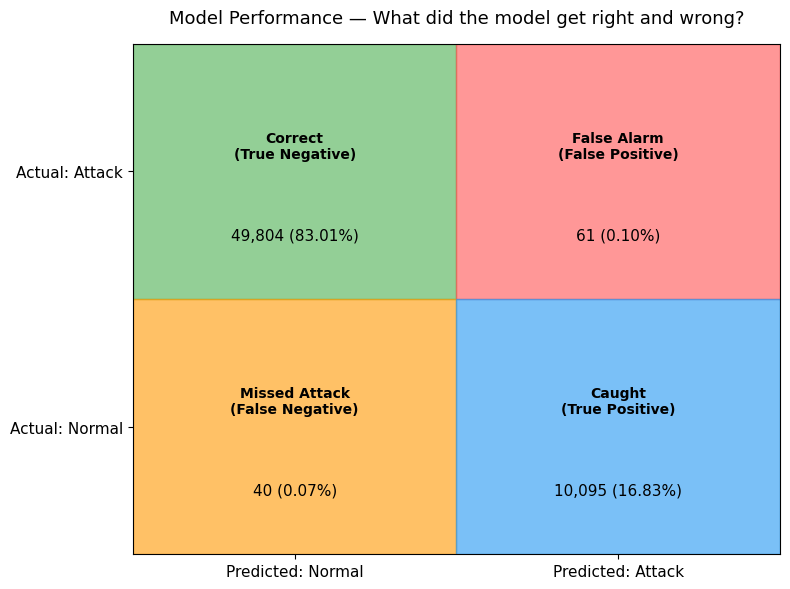

In [20]:
total = cm.sum()

colors = [['#4CAF50', '#FF5252'],
          ['#FF9800', '#2196F3']]

cell_labels = [['Correct\n(True Negative)', 'False Alarm\n(False Positive)'],
               ['Missed Attack\n(False Negative)', 'Caught\n(True Positive)']]

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle([j, 1-i], 1, 1, color=colors[i][j], alpha=0.6))
        percent = cm[i, j] / total * 100
        ax.text(j+0.5, 1-i+0.6, cell_labels[i][j],
                ha='center', va='center', fontsize=10, fontweight='bold')
        ax.text(j+0.5, 1-i+0.25, f"{cm[i,j]:,} ({percent:.2f}%)",
                ha='center', va='center', fontsize=11)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['Predicted: Normal', 'Predicted: Attack'], fontsize=11)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['Actual: Normal', 'Actual: Attack'], fontsize=11)
ax.set_title("Model Performance — What did the model get right and wrong?", fontsize=13, pad=15)

plt.tight_layout()
plt.show()

#Let's see on a Smaller Subset What are the predictions?

In [ ]:
X = df_small.drop(columns=["Attack Type", "is_attack"])
y = df_small["Attack Type"]

In [ ]:
X_cleaned = X.dropna()
y_cleaned = y[X_cleaned.index]

X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size = 0.2, stratify = y_cleaned, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (240000, 52)
Test size: (60000, 52)


In [ ]:
rfc=RandomForestClassifier(n_estimators=200,random_state =42,class_weight='balanced',n_jobs=-1,verbose=1,max_depth=20,        # limit depth
    min_samples_leaf=5,)

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
from sklearn.metrics import accuracy_score

print('Model accuracy score with 200 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))


NameError: name 'RandomForestClassifier' is not defined

In [ ]:
y_pred = rfc.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

print(confusion_matrix(y_test, y_pred))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.3s finished


                precision    recall  f1-score   support

          Bots     0.3727    0.8913    0.5256        46
   Brute Force     0.9956    0.9956    0.9956       225
          DDoS     0.9997    0.9983    0.9990      3026
           DoS     0.9935    0.9985    0.9960      4624
Normal Traffic     0.9996    0.9975    0.9986     49865
 Port Scanning     0.9899    0.9995    0.9947      2160
   Web Attacks     1.0000    0.9630    0.9811        54

      accuracy                         0.9976     60000
     macro avg     0.9073    0.9777    0.9272     60000
  weighted avg     0.9983    0.9976    0.9979     60000

[[   41     0     0     0     5     0     0]
 [    0   224     0     0     1     0     0]
 [    0     0  3021     0     5     0     0]
 [    0     0     0  4617     7     0     0]
 [   69     1     1    30 49742    22     0]
 [    0     0     0     0     1  2159     0]
 [    0     0     0     0     2     0    52]]


#Which Attribute is the Most Influential When Classifying the Different Types of Network Traffic?

In [ ]:
imp = pd.Series(rfc.feature_importances_, index=X.columns)
print(imp.sort_values(ascending=False).head(20))

Destination Port               0.115489
Init_Win_bytes_backward        0.069282
Packet Length Mean             0.044703
Total Length of Fwd Packets    0.042988
Fwd Packet Length Max          0.042746
Fwd Packet Length Mean         0.041606
Average Packet Size            0.041169
Subflow Fwd Bytes              0.036824
Bwd Packet Length Std          0.028405
Max Packet Length              0.026989
Bwd Header Length              0.026901
Bwd Packet Length Mean         0.025828
Flow Bytes/s                   0.025568
Init_Win_bytes_forward         0.024076
Flow IAT Max                   0.022510
Packet Length Variance         0.019365
Fwd Header Length              0.018425
Bwd Packet Length Max          0.018285
Bwd Packet Length Min          0.017784
Bwd Packets/s                  0.017647
dtype: float64


In [ ]:


def calculate_permutation_importance(estimator, X, y, attack_label):
    def custom_recall_scorer(estimator, X, y):
        y_pred = estimator.predict(X)
        return recall_score(y, y_pred, labels=[attack_label], average=None)[0]

    result = permutation_importance(
        estimator,
        X,
        y,
        scoring=custom_recall_scorer,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    return pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False).head(15)

#Each of the different attack cells will present the top ~20 attributes that are important to determining the attack itself in ascending order (Ex 0.07 = 7%)

##DoS Permutation Test


In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "DoS")



[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.3s finished


,0
Bwd Packet Length Std,0.076644
Destination Port,0.042820
Init_Win_bytes_backward,0.003547
Init_Win_bytes_forward,0.003460
min_seg_size_forward,0.001860
Packet Length Mean,0.001384
Fwd Header Length,0.001298
Fwd Packet Length Mean,0.001125
Flow Bytes/s,0.001038
Average Packet Size,0.000952


#DDoS Permutation Test


In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "DDoS")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.2s finished


,0
Destination Port,0.107601
Init_Win_bytes_backward,0.000727
Fwd IAT Std,0.000198
Total Length of Fwd Packets,0.000132
Fwd Packet Length Mean,0.000132
Packet Length Mean,0.000132
Fwd Packet Length Max,0.000132
Bwd Packets/s,0.000066
Total Fwd Packets,0.000000
Flow Duration,0.000000


#Port Scanning


In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "Port Scanning")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.3s finished


,0
Init_Win_bytes_backward,0.001852
Destination Port,0.001019
Bwd IAT Min,0.000463
Bwd Packet Length Std,0.000463
Bwd Packet Length Mean,0.000370
Init_Win_bytes_forward,0.000370
Bwd Packet Length Max,0.000278
Bwd Packet Length Min,0.000185
Packet Length Mean,0.000185
Bwd Packets/s,0.000185


#Brute Force

In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "Brute Force")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.6s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.7s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.7s finished


,0
Destination Port,0.979556
min_seg_size_forward,0.005333
Total Fwd Packets,0.000000
Flow Duration,0.000000
Fwd Packet Length Max,0.000000
Fwd Packet Length Min,0.000000
Fwd Packet Length Mean,0.000000
Fwd Packet Length Std,0.000000
Bwd Packet Length Max,0.000000
Bwd Packet Length Min,0.000000


#Web Attacks

In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "Web Attacks")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.3s finished


,0
Init_Win_bytes_backward,0.096296
Destination Port,0.062963
Fwd IAT Min,0.059259
Packet Length Mean,0.059259
Bwd Packets/s,0.051852
min_seg_size_forward,0.040741
Average Packet Size,0.040741
Fwd IAT Total,0.029630
Max Packet Length,0.025926
Init_Win_bytes_forward,0.018519


In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "Bots")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.2s finished


,0
Destination Port,0.643478
Init_Win_bytes_backward,0.404348
Init_Win_bytes_forward,0.365217
Bwd Packets/s,0.086957
Average Packet Size,0.060870
Bwd Packet Length Mean,0.047826
Flow IAT Std,0.039130
Flow Duration,0.039130
Flow IAT Max,0.034783
Flow Packets/s,0.034783


In [ ]:
X = df.drop(columns=["Attack Type", "is_attack"])
y = df["Attack Type"]

In [ ]:
X_cleaned = X.dropna()
y_cleaned = y[X_cleaned.index]

X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size = 0.2, stratify = y_cleaned, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2016600, 52)
Test size: (504151, 52)


In [ ]:
rfc=RandomForestClassifier(n_estimators=200,random_state =42,class_weight='balanced',n_jobs=-1,verbose=1,max_depth=20,        # limit depth
    min_samples_leaf=5,)

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
from sklearn.metrics import accuracy_score

print('Model accuracy score with 200 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  9.4min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed: 38.7min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 39.6min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.4s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   11.6s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:   12.0s finished


Model accuracy score with 200 decision-trees : 0.9964


In [ ]:
y_pred = rfc.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

print(confusion_matrix(y_test, y_pred))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   11.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:   11.3s finished


                precision    recall  f1-score   support

          Bots     0.2475    0.9640    0.3939       389
   Brute Force     0.9995    0.9995    0.9995      1830
          DDoS     0.9998    0.9997    0.9998     25603
           DoS     0.9965    0.9993    0.9979     35042
Normal Traffic     0.9999    0.9959    0.9979    355422
 Port Scanning     0.9896    0.9996    0.9946     18139
   Web Attacks     0.9612    0.9814    0.9712       429

      accuracy                         0.9965    436854
     macro avg     0.8849    0.9913    0.9078    436854
  weighted avg     0.9984    0.9965    0.9973    436854

[[   375      0      0      0     14      0      0]
 [     0   1829      0      0      1      0      0]
 [     0      0  25595      0      8      0      0]
 [     0      0      2  35018     18      1      3]
 [  1140      1      2    124 353956    189     10]
 [     0      0      0      0      4  18131      4]
 [     0      0      0      0      8      0    421]]


In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "DoS")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   10.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:   10.4s finished


,0
Destination Port,0.030558
Init_Win_bytes_backward,0.007779
Init_Win_bytes_forward,0.005862
Bwd Header Length,0.003373
min_seg_size_forward,0.002003
Fwd Header Length,0.001244
Packet Length Mean,0.000245
Max Packet Length,0.000200
Average Packet Size,0.000160
Flow Bytes/s,0.000126


In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "DDoS")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   10.5s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:   10.6s finished


,0
Destination Port,0.149295
Init_Win_bytes_backward,0.000547
Init_Win_bytes_forward,0.000172
FIN Flag Count,0.000086
Bwd Packets/s,0.000055
Bwd Header Length,0.000055
Max Packet Length,0.000039
Fwd IAT Max,0.000039
Packet Length Mean,0.000039
Flow Packets/s,0.000039


In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "Port Scanning")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.3s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   10.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:   10.2s finished


,0
Destination Port,0.000507
Fwd Header Length,0.000507
Init_Win_bytes_backward,0.000176
Packet Length Mean,0.000110
Max Packet Length,0.000110
Average Packet Size,0.000110
Fwd IAT Std,0.000088
Bwd Packets/s,0.000088
Total Fwd Packets,0.000088
Flow IAT Std,0.000077


In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "Brute Force")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    9.9s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:   10.1s finished


,0
Destination Port,0.987650
Init_Win_bytes_forward,0.010820
min_seg_size_forward,0.001530
Average Packet Size,0.001311
Flow IAT Std,0.001311
Max Packet Length,0.000984
Bwd Header Length,0.000984
Fwd Header Length,0.000874
Fwd IAT Min,0.000765
Init_Win_bytes_backward,0.000765


In [ ]:
calculate_permutation_importance(rfc, X_test, y_test, "Web Attacks")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   10.7s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:   10.9s finished


,0
Fwd IAT Min,0.082517
Init_Win_bytes_backward,0.046620
Init_Win_bytes_forward,0.023310
Destination Port,0.022844
Flow IAT Max,0.008858
Flow Duration,0.008392
Max Packet Length,0.007459
min_seg_size_forward,0.006527
Average Packet Size,0.006061
Fwd Packets/s,0.006061


#Conclusion / Results

This research analyzed the IDS-CIC2017 dataset using a Random Forest classifier to determine which network flow attributes are most influential when identifying different types of malicious traffic. Rather than optimizing strictly for overall accuracy, the primary focus was minimizing false negatives and false positives, as these metrics are more operationally meaningful in intrusion detection systems.

The binary classification model achieved very high recall and precision, demonstrating that flow-based statistical features are highly effective for distinguishing benign traffic from malicious activity. When extending the model to multiclass classification, most attack types were detected with strong recall and precision, though smaller classes such as Bots and Web Attacks showed more variability due to class imbalance.

Permutation importance testing revealed that different attack types rely on different behavioral fingerprints:

DoS detection relied heavily on backward packet variability and destination port characteristics.

DDoS detection was strongly influenced by destination port, suggesting potential dataset-specific bias.

Port Scanning showed distributed feature importance across multiple small statistical indicators rather than a single dominant feature.

Brute Force detection relied almost entirely on destination port, indicating service-specific behavior.

Web Attacks and Bots were more dependent on timing and TCP window-based features.

These results demonstrate that different attack types distort network behavior in unique statistical ways, and that feature importance analysis can uncover those behavioral signatures.

#What I Learned

Through this research, I learned that high overall accuracy is not sufficient when evaluating an intrusion detection system. Because network traffic is highly imbalanced, even small false positive rates can translate into thousands of alerts in large-scale environments.

I also learned that feature importance analysis is critical. It is not enough to know that a model performs well — understanding why it performs well is essential. Some attack types were strongly influenced by contextual features such as destination port, which may not generalize well across different network environments. Other attack types relied on distributed statistical patterns, which may be more robust in real-world applications.

Additionally, I observed that flow-level datasets capture behavioral statistics rather than payload content. This limits detection for subtle application-layer attacks but strengthens anomaly-based detection for volume and timing-based attacks.

#Use Cases

The results of this analysis have practical value beyond machine learning.

For a network engineer or network administrator, understanding which attributes are most influential provides guidance on what to monitor in real environments. For example:

High packet rates and abnormal TCP flag distributions may indicate DoS activity.

Repeated short connections to authentication ports may indicate brute force attempts.

Abnormal timing patterns or periodic small flows may indicate botnet communication.

Concentrated traffic toward specific services may indicate targeted attacks.


#Future Directions

If I had more time, these are the things I would've done:



Remove contextual features such as Destination Port to test generalization.

Evaluate the model on temporally separated data to assess robustness.

Compare Random Forest performance to Gradient Boosting or XGBoost.

Investigate feature grouping (e.g., removing all TCP window features) to better understand distributed signal.

Explore host-level aggregation features for attacks like Port Scanning.

Apply threshold tuning to explicitly balance precision and recall.

Testing the model on a different dataset would help determine whether the learned feature importance patterns generalize beyond IDS-CIC2017.